# Advanced Apex Project II

## Final Project Notebook

## Project Title: Retail Sales Amount Prediction & Customer Spending Analysis

---


**Programme:** M.Sc. Data Science & Artificial Intelligence

**Problem Statement:** P2 – Retail Sales Amount Prediction & Customer Spending Analysis

---

## Project Overview

Retail and e-commerce organizations generate large volumes of transactional data every day. Analysing this data can help businesses understand customer purchasing behaviour, improve inventory planning, optimize promotional strategies, and support data-driven decision making.

The objective of this project is to develop a supervised machine learning regression model capable of predicting retail sales amount using historical transaction data. The project will involve data preprocessing, exploratory data analysis, feature engineering, model building, hyperparameter tuning, and evaluation of multiple machine learning algorithms.

This notebook represents the Week-2 submission for Advanced Apex Project-II and focuses on project definition, dataset understanding, and planning of the complete machine learning workflow.

# 1. Problem Statement & Business Goal

## Problem Statement

### P2 – Retail Sales Amount Prediction & Customer Spending Analysis

Retail and e-commerce organizations seek to understand the factors that influence customer spending patterns in order to improve inventory planning, promotional strategies, and customer engagement.

The objective of this project is to develop a supervised machine learning regression model that can predict retail sales amount using historical transactional data. The project will involve data preprocessing, exploratory data analysis (EDA), feature engineering, model development, hyperparameter tuning, and comparison of multiple regression algorithms.

---

## Business Goal

In today's competitive retail environment, understanding customer purchasing behaviour is essential for effective business planning. Accurate prediction of sales amount can help organizations optimize inventory management, improve demand forecasting, and design targeted promotional campaigns.

The primary business objectives of this project are:

- To analyze historical retail transaction data.
- To identify the key factors influencing sales amount.
- To build a machine learning model capable of predicting transaction value.
- To compare multiple regression algorithms and identify the best-performing model.
- To improve model performance through hyperparameter tuning and validation techniques.
- To generate meaningful business insights from the predictive model.

---

## Expected Outcome

At the end of this project, a robust machine learning regression model will be developed that can accurately estimate retail sales amount while also providing insights into the factors that significantly influence customer spending behaviour.

# 2. Dataset Details

## Dataset Name

**Online Retail Dataset**

---

## Dataset Source

**UCI Machine Learning Repository**

https://archive.ics.uci.edu/dataset/352/online+retail

---

## Dataset Description

The Online Retail dataset contains all transactions occurring between December 2010 and December 2011 for a UK-based online retail company. Each record represents an individual item purchased within a transaction.

The dataset captures various aspects of retail transactions including invoice information, product details, purchase quantity, pricing, customer identification, and country of purchase.

---

## Dataset Size

- Total Records (Rows): **541,909**
- Total Features (Columns): **8**

---

## Dataset Attributes

| Feature | Description |
|----------|-------------|
| InvoiceNo | Unique invoice number |
| StockCode | Product/item code |
| Description | Product description |
| Quantity | Number of units purchased |
| InvoiceDate | Date and time of transaction |
| UnitPrice | Price per item |
| CustomerID | Unique customer identifier |
| Country | Country of the customer |

---

## Target Variable

The original dataset does not contain a dedicated sales amount column. Therefore, a derived target variable will be created as:

### InvoiceAmount = Quantity × UnitPrice

This variable represents the monetary value of each transaction and will serve as the dependent variable for the regression models developed during the project.

---

## Why This Dataset Was Selected

This dataset was selected because it contains real-world transactional retail data and provides sufficient opportunities for:

- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Regression modelling
- Hyperparameter tuning
- Model comparison
- Business interpretation

The richness and size of the dataset make it suitable for demonstrating the complete machine learning workflow expected in Advanced Apex Project-II.

---

In [42]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("Required libraries imported successfully.")

Required libraries imported successfully.


# 3. Initial Dataset Understanding

The first step in any machine learning project is to understand the structure and quality of the dataset.

Before performing any preprocessing or modelling, the following checks will be carried out:

- Load the dataset into the Google Colab environment.
- Examine the first few records.
- Determine the dataset dimensions.
- Review the available features.
- Check data types.
- Identify missing values.
- Generate summary statistics.

These initial observations will help identify potential preprocessing requirements and expected challenges for the later stages of the project.

---

In [43]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loading the Dataset

The dataset has been stored in Google Drive and will be loaded into the notebook using the Pandas library.

The dataset is provided in Excel format (.xlsx).

---

In [44]:
# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# ============================================================
# Load Dataset
# ============================================================

file_path = "/content/drive/MyDrive/MSc_Trimester3_ApexProject2/Online_Retail.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [46]:
# Display first five rows

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [47]:
# Dataset dimensions

print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 541909
Number of Columns : 8


In [48]:
# Display column names

df.columns.tolist()

['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [49]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [50]:
# Summary statistics for numerical columns

df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [51]:
# Check missing values

df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [52]:
# ============================================================
# Create Target Variable
# ============================================================

df["InvoiceAmount"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "InvoiceAmount"]].head()

,Quantity,UnitPrice,InvoiceAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## Initial Observations

Based on the preliminary inspection of the dataset, the following observations can be made:

- The dataset contains **541,909 transaction records** and **8 features**.
- Both numerical and categorical variables are present.
- The `InvoiceDate` column has already been recognized as a datetime variable, which will be useful for future feature engineering.
- The `Description` column contains **1,454 missing values**.
- The `CustomerID` column contains **135,080 missing values**, indicating that some transactions are not associated with registered customers.
- The `Quantity` feature contains negative values, suggesting the presence of product returns or cancelled transactions.
- The `UnitPrice` feature also contains some negative values, which may represent adjustments or data quality issues and will require further investigation.
- A new target variable, **InvoiceAmount**, will be created using:

### InvoiceAmount = Quantity × UnitPrice

This derived variable will be used as the dependent variable for the regression models developed during this project.

## Expected Challenges

Based on the initial inspection, the following preprocessing challenges are anticipated:

- Handling missing values in the `Description` and `CustomerID` columns.
- Identifying and managing returned or cancelled transactions.
- Investigating and treating negative or unusual pricing values.
- Detecting and handling outliers.
- Encoding categorical variables for machine learning algorithms.
- Performing feature engineering to improve predictive performance.
- Preventing model overfitting and improving generalization through appropriate validation and hyperparameter tuning.

These observations will guide the preprocessing and modelling stages in the subsequent weeks of the project.

# 4. Proposed Workflow

The objective of this project is to develop a robust machine learning regression model for predicting retail sales amount using historical transaction data.

The project will follow a structured machine learning pipeline consisting of the following stages:

---

## Step 1: Data Collection and Loading

- Obtain the Online Retail dataset from the UCI Machine Learning Repository.
- Load the dataset into the Google Colaboratory environment.
- Perform initial inspection of the dataset structure.

---

## Step 2: Data Preprocessing (DPP)

The preprocessing phase will focus on improving data quality and preparing the dataset for analysis.

Planned activities include:

- Handling missing values.
- Identifying and removing duplicate records.
- Managing returned or cancelled transactions.
- Investigating negative quantity and pricing values.
- Handling outliers.
- Creating the target variable (InvoiceAmount).

---

## Step 3: Exploratory Data Analysis (EDA)

Exploratory analysis will be performed to understand the underlying patterns within the data.

Planned analyses include:

- Distribution of sales amount.
- Country-wise transaction analysis.
- Quantity and UnitPrice distributions.
- Customer purchasing behaviour.
- Time-based sales trends.
- Correlation analysis among numerical variables.

Visualizations will be created using Matplotlib and Seaborn libraries.

---

## Step 4: Feature Engineering (FE)

Feature engineering will be performed to improve model performance and capture additional business insights.

Potential features include:

- Transaction Value (InvoiceAmount).
- Invoice Year.
- Invoice Month.
- Invoice Day.
- Invoice Weekday.
- Invoice Hour.
- Customer purchase frequency.
- Average purchase amount.
- Country-based indicators.

Feature encoding and scaling techniques will also be applied where required.

---

## Step 5: Model Development

The dataset will be divided into training and testing subsets.

An initial baseline model will be developed using Linear Regression.

Subsequently, multiple advanced regression algorithms will be trained and compared.

---

## Step 6: Hyperparameter Tuning

Hyperparameter optimization will be performed to improve model generalization performance and reduce overfitting.

The tuning process will utilize:

- GridSearchCV
- K-Fold Cross Validation

Different parameter combinations will be evaluated for each regression model.

---

## Step 7: Model Evaluation

The trained models will be evaluated using multiple regression performance metrics.

Planned evaluation metrics include:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

Residual analysis and cross-validation scores will also be examined.

---

## Step 8: Model Comparison and Interpretation

The final stage of the project will focus on comparing the performance of all candidate models.

The project will also analyse:

- Feature importance.
- Model generalization ability.
- Impact of hyperparameter tuning.
- Business insights obtained from the predictive model.

The best-performing model will be selected based on both predictive accuracy and generalization performance.

---

# 5. Proposed Baseline & Advanced Models

The objective of this project is not only to build a predictive model but also to compare multiple machine learning algorithms and identify the approach that provides the best balance between prediction accuracy and model generalization.

Different regression algorithms have different strengths and assumptions. Therefore, multiple models will be developed, evaluated, and compared during the course of this project.

---

## Proposed Baseline Model

### Linear Regression

Linear Regression has been selected as the baseline model because it is simple, computationally efficient, and easy to interpret.

The baseline model will provide an initial benchmark against which the performance of more advanced machine learning algorithms can be evaluated.

### Advantages of Linear Regression

- Simple and interpretable.
- Fast model training.
- Provides a strong baseline for regression problems.
- Easy to understand the relationship between features and target variable.

---

## Proposed Advanced Models

After establishing the baseline performance, the following advanced regression algorithms will be implemented and compared.

### 1. Decision Tree Regressor

A tree-based supervised learning algorithm capable of capturing non-linear relationships between input features and the target variable.

Potential strengths:

- Handles non-linear patterns.
- Easy to visualize and interpret.
- Requires minimal feature scaling.

---

### 2. Random Forest Regressor

An ensemble learning technique that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

Potential strengths:

- Better generalization.
- Robust against overfitting.
- Handles large datasets effectively.
- Provides feature importance information.

---

### 3. Gradient Boosting Regressor

A boosting algorithm that builds models sequentially, where each new model attempts to correct the errors made by previous models.

Potential strengths:

- High predictive performance.
- Effective for complex relationships.
- Strong capability to reduce prediction errors.

---

### 4. K-Nearest Neighbours (KNN) Regressor

A non-parametric algorithm that predicts values based on the average of nearby observations.

Potential strengths:

- Simple concept.
- No explicit model assumptions.
- Useful for capturing local data patterns.

---

## Model Comparison Strategy

All candidate models will be trained using the same training and testing datasets.

Their performances will be compared using multiple evaluation metrics and cross-validation techniques.

The comparison will focus on:

- Prediction accuracy.
- Generalization capability.
- Sensitivity to hyperparameter tuning.
- Computational efficiency.
- Business interpretability.

The final model will be selected based on its overall performance and ability to generalize well to unseen data.

---

# 6. Evaluation Metrics & Tuning Plan

A machine learning model cannot be evaluated based on prediction alone. Multiple evaluation metrics will be used to assess the accuracy, robustness, and generalization capability of each regression model.

The objective is to identify the model that not only performs well on the training data but also generalizes effectively to unseen data.

---

## Evaluation Metrics

The following regression metrics will be used for model evaluation:

### 1. Mean Absolute Error (MAE)

Mean Absolute Error measures the average absolute difference between the actual and predicted values.

Lower MAE values indicate better model performance.

---

### 2. Mean Squared Error (MSE)

Mean Squared Error calculates the average squared difference between actual and predicted values.

Because errors are squared, larger prediction errors receive greater penalties.

Lower MSE values indicate better model performance.

---

### 3. Root Mean Squared Error (RMSE)

RMSE is the square root of the Mean Squared Error and is expressed in the same units as the target variable.

It provides an intuitive measure of prediction error.

Lower RMSE values indicate higher prediction accuracy.

---

### 4. R² Score (Coefficient of Determination)

The R² Score measures how well the independent variables explain the variation in the target variable.

An R² value closer to 1 indicates better model fit.

---

## Additional Model Assessment

In addition to the primary evaluation metrics, the following techniques will be used to assess model quality:

- Train-Test performance comparison.
- Cross-validation.
- Residual analysis.
- Model generalization assessment.
- Overfitting and underfitting analysis.

These analyses will help ensure that the selected model performs consistently on unseen data.

---

## Hyperparameter Tuning Strategy

Hyperparameter tuning will be performed to improve model performance and reduce overfitting.

The tuning process will involve systematic experimentation with different parameter combinations for each candidate model.

### Planned Optimization Techniques

- GridSearchCV
- K-Fold Cross Validation

---

## Parameters Planned for Experimentation

### Decision Tree Regressor

- max_depth
- min_samples_split
- min_samples_leaf

---

### Random Forest Regressor

- n_estimators
- max_depth
- min_samples_split
- max_features

---

### Gradient Boosting Regressor

- learning_rate
- n_estimators
- max_depth

---

### K-Nearest Neighbours Regressor

- n_neighbors
- weights
- metric

---

## Expected Outcome

The impact of different hyperparameter settings on prediction accuracy, model stability, and generalization performance will be analysed.

The final model will be selected based on its overall performance across multiple evaluation metrics rather than a single accuracy measure.

---

# 7. Tools & Technologies

The project will be implemented using Python and the Google Colaboratory environment. The following tools, libraries, and frameworks will be used throughout the machine learning workflow.

---

## Programming Language

- Python 3.x

---

## Development Environment

- Google Colaboratory (Google Colab)

---

## Cloud Storage

- Google Drive

---

## Data Manipulation Libraries

- Pandas
- NumPy

---

## Data Visualization Libraries

- Matplotlib
- Seaborn

---

## Machine Learning Framework

- Scikit-learn

---

## Hyperparameter Tuning Utilities

- GridSearchCV
- K-Fold Cross Validation

---

## Dataset Repository

- UCI Machine Learning Repository

---

## Version Control (Optional)

- Git / GitHub (for project backup and version management)

---

These tools have been selected because they provide a comprehensive ecosystem for data preprocessing, exploratory data analysis, feature engineering, machine learning model development, and performance evaluation.

---

# 8. References

The following resources have been referred to during the planning and implementation of this project.

---

## Dataset Source

UCI Machine Learning Repository

Online Retail Dataset

https://archive.ics.uci.edu/dataset/352/online+retail

---

## Project Reference

Advanced Apex Project-II

Problem Statement: P2 – Retail Sales Amount Prediction & Customer Spending Analysis

M.Sc. Data Science & Artificial Intelligence

---

## Python Documentation

https://docs.python.org/3/

---

## Pandas Documentation

https://pandas.pydata.org/docs/

---

## NumPy Documentation

https://numpy.org/doc/

---

## Matplotlib Documentation

https://matplotlib.org/stable/

---

## Seaborn Documentation

https://seaborn.pydata.org/

---

## Scikit-learn Documentation

https://scikit-learn.org/stable/

---

## Google Colaboratory

https://colab.research.google.com/

---

# Week 2 Summary

The following activities have been completed as part of the Week-2 submission:

✅ Problem Statement Selection

✅ Business Goal Definition

✅ Dataset Selection

✅ Dataset Loading and Initial Inspection

✅ Initial Dataset Understanding

✅ Identification of Potential Data Challenges

✅ Planning of Data Preprocessing, EDA, and Feature Engineering

✅ Selection of Baseline and Advanced Machine Learning Models

✅ Definition of Evaluation Metrics and Hyperparameter Tuning Strategy

✅ Identification of Tools, Technologies, and Project References

---

## Planned Activities for Next Phase

The next stage of the project will focus on:

- Data Cleaning
- Missing Value Treatment
- Handling Returns and Cancelled Transactions
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preparation for Model Development

---

This notebook serves as the initial planning and dataset understanding document for the Advanced Apex Project-II and establishes the foundation for the subsequent machine learning workflow.

#Week 2 Feedback Implementation

# Preliminary Exploratory Data Analysis (EDA)

The purpose of this preliminary exploratory data analysis is to obtain an initial understanding of the dataset by examining its structure, missing values, feature distributions, and customer transaction patterns.

These analyses will guide subsequent data preprocessing, feature engineering, and model development activities.

In [53]:
# ============================================================
# Dataset Statistics
# ============================================================

print("Dataset Shape :", df.shape)

print("\nNumber of Rows :", df.shape[0])

print("Number of Columns :", df.shape[1])

print("\nData Types")

display(df.dtypes)

print("\nMissing Values")

display(df.isnull().sum())

Dataset Shape : (541909, 9)

Number of Rows : 541909
Number of Columns : 9

Data Types


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object
InvoiceAmount,float64



Missing Values


,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0
InvoiceAmount,0


## Initial exploration of the dataset: Observations

Based on the initial exploration of the dataset, the following observations can be made:

* The dataset contains **541,909 transaction records** and **9 features**, including the newly created target variable (**InvoiceAmount**).
* The dataset consists of **4 categorical features**, **3 numerical features**, **1 datetime feature**, and **1 derived numerical target variable**.
* The `CustomerID` column contains **135,080 missing values**, indicating that a significant number of transactions are not associated with registered customers.
* The `Description` column contains **1,454 missing values**, which will require appropriate preprocessing.
* No missing values are present in the remaining features, including the newly created `InvoiceAmount`.
* The `InvoiceDate` column has been successfully recognized as a datetime variable, making it suitable for extracting time-based features during feature engineering.
* The dataset contains both transactional and customer-related information, making it suitable for developing a supervised machine learning regression model for retail sales amount prediction.


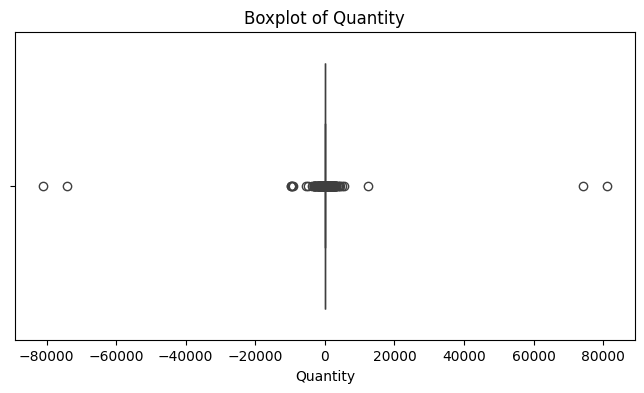

In [54]:
# Boxplot of Quantity

plt.figure(figsize=(8,4))

sns.boxplot(x=df["Quantity"])

plt.title("Boxplot of Quantity")

plt.xlabel("Quantity")

plt.show()

### Quality Observations

The boxplot indicates the presence of several extreme values (outliers) in the **Quantity** feature. Most transactions involve relatively small purchase quantities, while a limited number of transactions have exceptionally high positive or negative quantities. These extreme values are likely to represent bulk purchases, product returns, or cancelled transactions and will be investigated further during the data preprocessing stage.

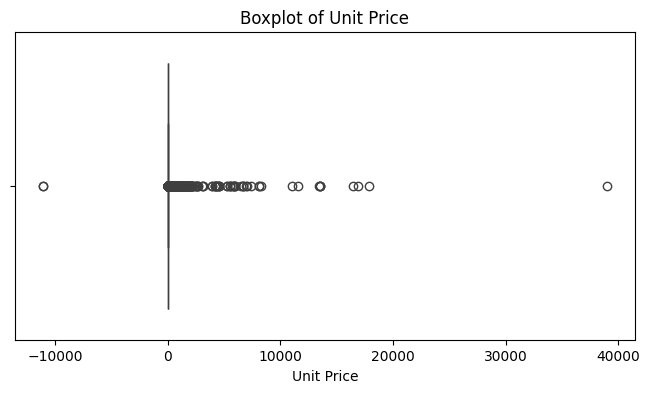

In [55]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["UnitPrice"])

plt.title("Boxplot of Unit Price")

plt.xlabel("Unit Price")

plt.show()

### Unit Price Observation

The boxplot indicates that the **UnitPrice** feature contains several extreme values (outliers), including both unusually high and negative prices. While most products are sold at relatively low prices, a small number of transactions have exceptionally high or negative unit prices, which may represent pricing adjustments, refunds, or data entry inconsistencies. These values will be further investigated during the data preprocessing stage before model development.

#### Data Preparation

Before performing further exploratory analysis and machine learning, the dataset was cleaned to improve data quality and ensure reliable model development.

The preprocessing steps included:

- Creating a cleaned dataset (`df_model`)
- Removing records with missing CustomerID values
- Removing cancelled or returned transactions (Quantity ≤ 0)
- Removing invalid UnitPrice values
- Creating the target variable (InvoiceAmount)
- Extracting preliminary temporal features from InvoiceDate (InvoiceYear, InvoiceMonth, InvoiceDay, InvoiceWeekday, and InvoiceHour)

The cleaned and feature-enhanced dataset was subsequently used for exploratory analysis and predictive modelling.

In [56]:
# ============================================================
# Data Preparation
# ============================================================

df_model = df.copy()

# Remove rows with missing CustomerID
df_model = df_model.dropna(subset=["CustomerID"])

# Remove cancelled/returned transactions
df_model = df_model[df_model["Quantity"] > 0]

# Remove invalid prices
df_model = df_model[df_model["UnitPrice"] > 0]

# Create target variable
df_model["InvoiceAmount"] = (
    df_model["Quantity"] * df_model["UnitPrice"]
)

# Date features
df_model["InvoiceYear"] = df_model["InvoiceDate"].dt.year
df_model["InvoiceMonth"] = df_model["InvoiceDate"].dt.month
df_model["InvoiceDay"] = df_model["InvoiceDate"].dt.day
df_model["InvoiceWeekday"] = df_model["InvoiceDate"].dt.day_name()
df_model["InvoiceHour"] = df_model["InvoiceDate"].dt.hour

print("Cleaned Dataset Shape:", df_model.shape)

df_model.head()

Cleaned Dataset Shape: (397884, 14)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceAmount,InvoiceYear,InvoiceMonth,InvoiceDay,InvoiceWeekday,InvoiceHour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,8


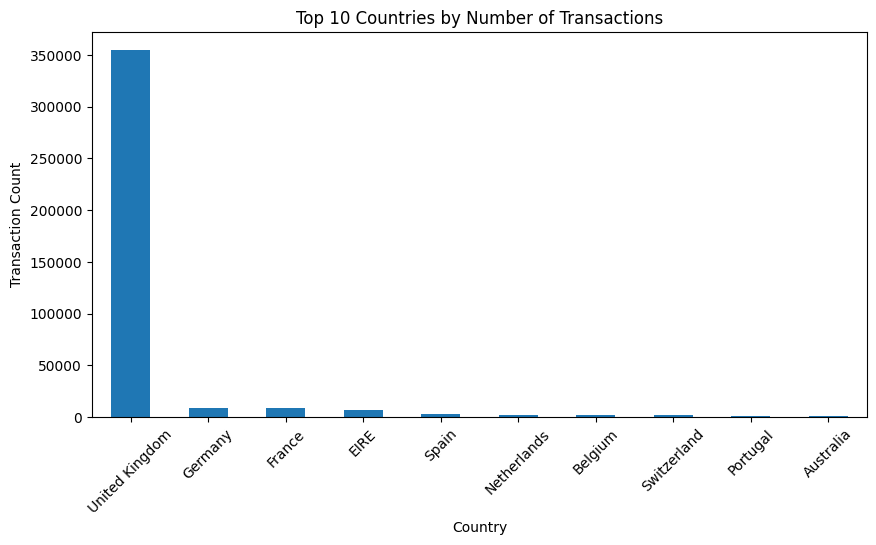

In [57]:
plt.figure(figsize=(10,5))

df_model["Country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries by Number of Transactions")

plt.xlabel("Country")

plt.ylabel("Transaction Count")

plt.xticks(rotation=45)

plt.show()

### No of Transaction Observation

The visualization shows that the **United Kingdom** accounts for the overwhelming majority of retail transactions, significantly exceeding all other countries in the dataset. Germany, France, EIRE, Spain, the Netherlands, Belgium, Switzerland, Portugal, and Australia contribute comparatively fewer transactions.

This indicates that the retail company primarily serves customers in the United Kingdom, resulting in an imbalanced geographical distribution of transactions. Such insights are useful for understanding customer demographics, planning market expansion strategies, and developing region-specific sales and marketing initiatives.

## Correlation Analysis

Correlation analysis was performed to examine the relationships among numerical variables used in regression modelling. Understanding these relationships helps identify important predictor variables and provides insight into how strongly each feature is associated with the target variable (InvoiceAmount).

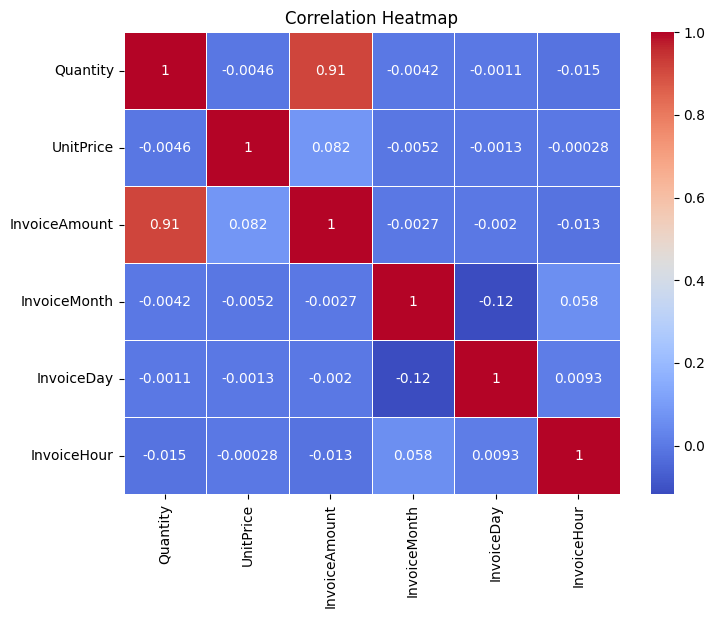

In [58]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

correlation = df_model[
    [
        "Quantity",
        "UnitPrice",
        "InvoiceAmount",
        "InvoiceMonth",
        "InvoiceDay",
        "InvoiceHour"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows that **Quantity** has a very strong positive correlation (**0.91**) with the target variable **InvoiceAmount**, indicating that the number of items purchased is the primary factor influencing the total transaction value.

In contrast, **UnitPrice** exhibits only a weak positive correlation (**0.082**) with InvoiceAmount, suggesting that variation in transaction values within this dataset is driven more by purchase quantity than by individual product prices.

The temporal features (**InvoiceMonth**, **InvoiceDay**, and **InvoiceHour**) display very weak correlations with the target variable, indicating that the timing of transactions has relatively little direct influence on invoice value.

Overall, the analysis suggests that transaction characteristics, particularly purchase quantity, play a much more significant role in predicting retail sales amount than temporal attributes.

## Monthly Sales Trend

Monthly sales analysis helps identify seasonal purchasing patterns and understand how retail sales vary throughout the year. Such insights can assist businesses in inventory planning, demand forecasting, and promotional campaign scheduling.

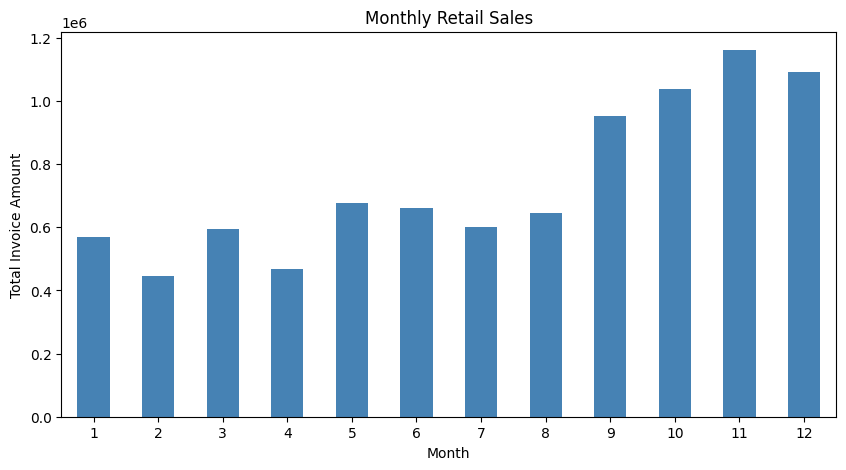

In [59]:
# Monthly Sales Trend

monthly_sales = (
    df_model
    .groupby("InvoiceMonth")["InvoiceAmount"]
    .sum()
)

plt.figure(figsize=(10,5))

monthly_sales.plot(
    kind="bar",
    color="steelblue"
)

plt.title("Monthly Retail Sales")

plt.xlabel("Month")

plt.ylabel("Total Invoice Amount")

plt.xticks(rotation=0)

plt.show()

### Observation

The monthly sales trend indicates noticeable seasonal variation in retail sales throughout the year. Sales remain relatively moderate during the first half of the year, followed by a steady increase from **September onwards**. The highest total sales are observed in **November**, while **December** also records strong sales despite being slightly lower than November.

This trend suggests increased customer purchasing activity during the final quarter of the year, which may be associated with seasonal demand and holiday shopping. Such insights can support inventory planning, demand forecasting, staffing decisions, and promotional campaign scheduling during peak sales periods.

## Distribution of Invoice Amount

The distribution of the target variable (**InvoiceAmount**) was analysed to understand the spread of transaction values. Examining the target distribution helps identify skewness, outliers, and the overall characteristics of retail sales transactions, which are important considerations when developing regression models.

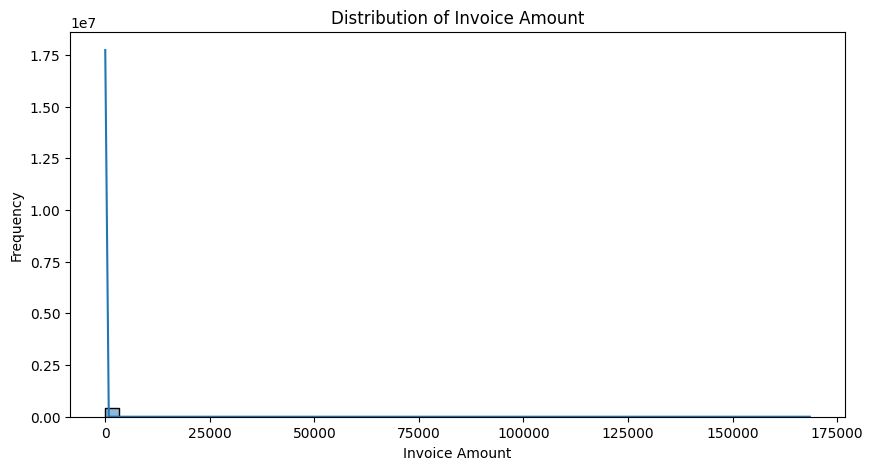

In [60]:
# Distribution of Invoice Amount

plt.figure(figsize=(10,5))

sns.histplot(
    df_model["InvoiceAmount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Invoice Amount")

plt.xlabel("Invoice Amount")

plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of **InvoiceAmount** is highly **right-skewed**, indicating that the majority of transactions involve relatively small invoice amounts, while a small number of transactions have exceptionally high values.

The presence of these high-value transactions suggests the existence of outliers, which is common in retail sales datasets where occasional bulk purchases or high-value orders occur. Such skewed distributions can influence regression model performance and should be considered during model evaluation and interpretation.

Overall, the distribution indicates that retail sales are dominated by frequent low-value transactions with comparatively few high-value purchases.

### Log-Transformed Distribution of Invoice Amount

To better visualize the distribution of invoice amounts, a logarithmic transformation was applied. This reduces the effect of extreme outliers and provides a clearer view of the underlying transaction value distribution.

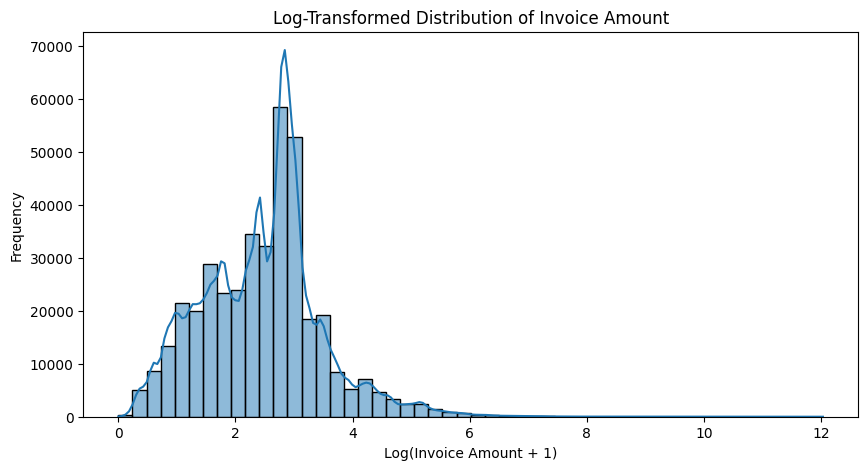

In [61]:
# Log-transformed Invoice Amount Distribution

plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df_model["InvoiceAmount"]),
    bins=50,
    kde=True
)

plt.title("Log-Transformed Distribution of Invoice Amount")

plt.xlabel("Log(Invoice Amount + 1)")

plt.ylabel("Frequency")

plt.show()

#### Observation

The log transformation significantly reduces the effect of extreme invoice values, making the underlying distribution easier to interpret. Compared to the original distribution, the transformed data appears much more concentrated with a moderate right skew, indicating that most transactions fall within a similar range after accounting for the influence of large purchases.

This visualization confirms that the extreme values observed in the original distribution are responsible for the heavy skewness. Log transformation is a useful exploratory technique for understanding highly skewed retail transaction data and can be considered during future modelling experiments if required.

## Preliminary Feature Engineering

During the Data Preparation stage, several initial features were engineered from the cleaned transactional dataset to support exploratory data analysis and predictive modelling.

The engineered features include:

- InvoiceAmount (Target Variable)
- InvoiceYear
- InvoiceMonth
- InvoiceDay
- InvoiceWeekday
- InvoiceHour

These variables capture the monetary and temporal characteristics of each transaction and provide additional information for subsequent analysis and machine learning models.

## Feature Engineering Summary

The preliminary feature engineering performed during the Data Preparation stage generated several additional variables that improve the analytical and predictive capability of the dataset.

The following features were genereated:

| Feature            | Description                                                                  |
| ------------------ | ---------------------------------------------------------------------------- |
| **InvoiceAmount**  | Total transaction value calculated as Quantity × UnitPrice (Target Variable) |
| **InvoiceYear**    | Year of transaction                                                          |
| **InvoiceMonth**   | Month of transaction                                                         |
| **InvoiceDay**     | Day of the month                                                             |
| **InvoiceWeekday** | Day of the week on which the transaction occurred                            |
| **InvoiceHour**    | Hour of the transaction                                                      |

These engineered features capture the monetary and temporal characteristics of customer transactions and are expected to contribute to improved model performance during the subsequent modelling stage.

The cleaned dataset now contains the original transactional variables together with the engineered monetary and temporal features, providing a richer feature set for exploratory analysis and predictive modelling.


The enhanced feature set was subsequently used during model development and evaluation to improve predictive capability and support comparison across multiple regression algorithms.

# Week 5 Progress Update

This section extends the Week-2 work by implementing data preparation, baseline modelling, model comparison, preliminary hyperparameter tuning, and initial evaluation.

The objective is to establish an initial machine learning pipeline that will be further refined in the final submission.

## Week 5 Feedback Implementation Summary

Based on the feedback received after the Week 5 submission, several improvements were implemented to strengthen the overall machine learning workflow and address the identified gaps.

### Improvements Implemented

**Data Preparation**
- Implemented handling of missing values in the **Description** column.
- Removed duplicate transaction records.
- Converted **CustomerID** to the appropriate integer data type.
- Performed additional data cleaning to improve dataset quality.

**Exploratory Data Analysis (EDA)**
- Added correlation analysis using a heatmap.
- Analysed monthly retail sales trends.
- Examined the distribution of invoice amounts.
- Performed log transformation to better understand the highly skewed target variable.
- Added business-oriented observations for every visualization.

**Feature Engineering**
- Created additional temporal features including **Quarter** and **Weekend**.
- Updated the modelling dataset to incorporate the newly engineered features.

**Machine Learning**
- Retrained regression models using the cleaned dataset.
- Performed hyperparameter tuning for the Decision Tree Regressor using GridSearchCV.
- Added a Random Forest Regressor for model comparison.
- Compared model performance using R² Score, MAE, and RMSE.

**Model Interpretation**
- Added Feature Importance analysis.
- Included a discussion on model generalization and overfitting.
- Expanded the evaluation and business interpretation sections.

## Final Submission Enhancements

The final submission extends the initial project by implementing a complete end-to-end machine learning workflow.

### Additional Enhancements

- Completed comprehensive data cleaning and preprocessing.
- Performed detailed exploratory data analysis with statistical interpretation.
- Added correlation analysis and seasonal sales trend analysis.
- Investigated the distribution of the target variable using both original and log-transformed visualizations.
- Enhanced feature engineering through additional temporal variables.
- Developed and compared multiple regression models.
- Performed hyperparameter tuning using GridSearchCV.
- Compared models using multiple evaluation metrics.
- Analysed feature importance to understand model behaviour.
- Included overfitting and generalization discussion.
- Expanded documentation, observations, business insights, and final conclusions.

These enhancements improve the completeness, reproducibility, and practical business relevance of the project while addressing the feedback received during earlier project submissions.

## Additional Data Cleaning

To improve data quality before model development, additional preprocessing steps were performed:

- Missing values in the **Description** column were replaced with `"Unknown"` since this field is descriptive and does not directly influence the regression target.
- Duplicate transaction records were identified and removed to avoid bias during model training.
- The **CustomerID** column was converted to an integer data type after removing missing values to ensure consistent data representation.

These steps improve dataset consistency and help create a cleaner dataset for subsequent analysis and modelling.

In [62]:
# Fill missing values in Description
df_model["Description"] = df_model["Description"].fillna("Unknown")

# Check duplicate records
print("Duplicate records before removal:", df_model.duplicated().sum())

# Remove duplicates
df_model = df_model.drop_duplicates()

print("Duplicate records after removal:", df_model.duplicated().sum())

# Convert CustomerID to integer
df_model["CustomerID"] = df_model["CustomerID"].astype(int)

# Display data types
print("\nUpdated Data Types:")
print(df_model.dtypes)

# Final dataset shape
print("\nFinal Dataset Shape:", df_model.shape)

Duplicate records before removal: 5192
Duplicate records after removal: 0

Updated Data Types:
InvoiceNo                 object
StockCode                 object
Description               object
Quantity                   int64
InvoiceDate       datetime64[ns]
UnitPrice                float64
CustomerID                 int64
Country                   object
InvoiceAmount            float64
InvoiceYear                int32
InvoiceMonth               int32
InvoiceDay                 int32
InvoiceWeekday            object
InvoiceHour                int32
dtype: object

Final Dataset Shape: (392692, 14)


## Enhanced Feature Engineering

Following the additional data cleaning process, two new temporal variables were created to further improve the modelling dataset.

- **Quarter** – Represents the quarter of the year in which the transaction occurred.
- **Weekend** – Indicates whether the transaction occurred during the weekend (1) or a weekday (0).

These engineered features provide additional information about seasonal purchasing behaviour and customer shopping patterns, which may improve model performance.

In [63]:
# ============================================================
# Enhanced Feature Engineering
# ============================================================

# Quarter of the year
df_model["Quarter"] = df_model["InvoiceDate"].dt.quarter

# Weekend Indicator
df_model["Weekend"] = (
    df_model["InvoiceDate"].dt.dayofweek >= 5
).astype(int)

print("Enhanced Feature Engineering Completed Successfully!")

display(
    df_model[
        [
            "InvoiceDate",
            "InvoiceMonth",
            "Quarter",
            "Weekend"
        ]
    ].head()
)

Enhanced Feature Engineering Completed Successfully!


,InvoiceDate,InvoiceMonth,Quarter,Weekend
0,2010-12-01 08:26:00,12,4,0
1,2010-12-01 08:26:00,12,4,0
2,2010-12-01 08:26:00,12,4,0
3,2010-12-01 08:26:00,12,4,0
4,2010-12-01 08:26:00,12,4,0


In [64]:
print(df_model["Weekend"].value_counts())

Weekend
0    331480
1     61212
Name: count, dtype: int64


In [65]:
print(df_model["Quarter"].value_counts())

Quarter
4    154657
3     93039
2     77432
1     67564
Name: count, dtype: int64


# Baseline Model – Linear Regression

A baseline model is developed to establish an initial benchmark for predicting the target variable (InvoiceAmount). The performance of this model will be compared with more advanced machine learning algorithms in later stages of the project.

In [66]:
# ============================================================
# Baseline Model - Linear Regression
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features
X = df_model[
    [
        "Quantity",
        "UnitPrice",
        "InvoiceMonth",
        "InvoiceDay",
        "InvoiceHour",
        "Quarter",
        "Weekend"
    ]
]
# Target
y = df_model["InvoiceAmount"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
lr = LinearRegression()

lr.fit(X_train, y_train)

# Prediction
y_pred = lr.predict(X_test)

print("Baseline Model Trained Successfully")

print("R2 Score :", r2_score(y_test,y_pred))

print("MAE :", mean_absolute_error(y_test,y_pred))

print("RMSE :", mean_squared_error(y_test,y_pred)**0.5)

Baseline Model Trained Successfully
R2 Score : 0.7494410878018876
MAE : 13.266955942405449
RMSE : 303.1427870963679


## Actual vs Predicted Values (Linear Regression)

To visually evaluate the performance of the baseline Linear Regression model, the actual invoice amounts are compared with the predicted values.

If the model performs well, the predicted values should closely follow the actual values and lie near the diagonal reference line. Large deviations from the line indicate prediction errors.

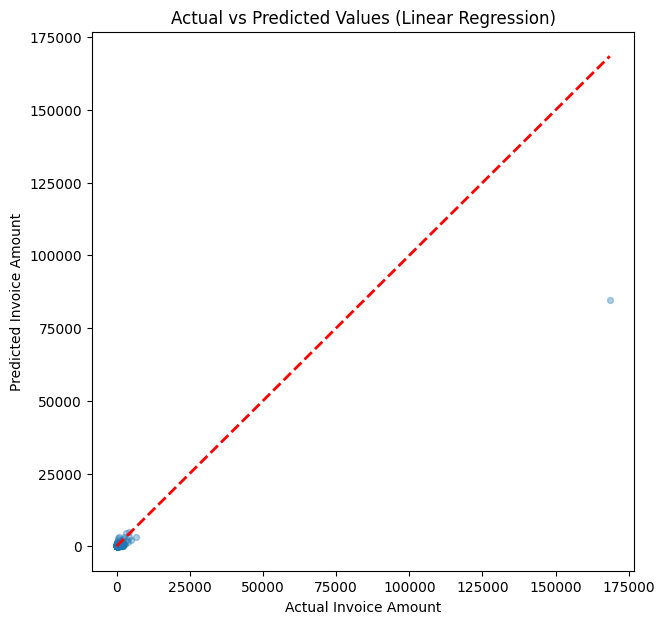

In [75]:
# ============================================================
# Actual vs Predicted - Linear Regression
# ============================================================

plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred, alpha=0.35, s=18)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Invoice Amount")
plt.ylabel("Predicted Invoice Amount")
plt.title("Actual vs Predicted Values (Linear Regression)")

plt.show()

### Observation

The Actual vs Predicted scatter plot shows that most low- and medium-value transactions are predicted reasonably well by the Linear Regression model, as many observations lie close to the diagonal reference line.

However, a small number of high-value transactions are noticeably under-predicted. In particular, one extreme invoice amount is predicted much lower than its actual value, indicating that the baseline Linear Regression model struggles to capture unusually large purchases.

This behaviour is expected because the Online Retail dataset contains a highly skewed distribution of invoice amounts with a few extreme outliers. Overall, the model performs satisfactorily for the majority of transactions but has reduced accuracy for very high-value invoices.

## Residual Analysis (Linear Regression)

Residual analysis helps evaluate how well the Linear Regression model fits the data.

Residuals are calculated as the difference between the actual and predicted invoice amounts.

A good regression model should produce residuals that are randomly scattered around zero without showing any clear pattern. Systematic patterns may indicate that the model is unable to capture some relationships present in the data.

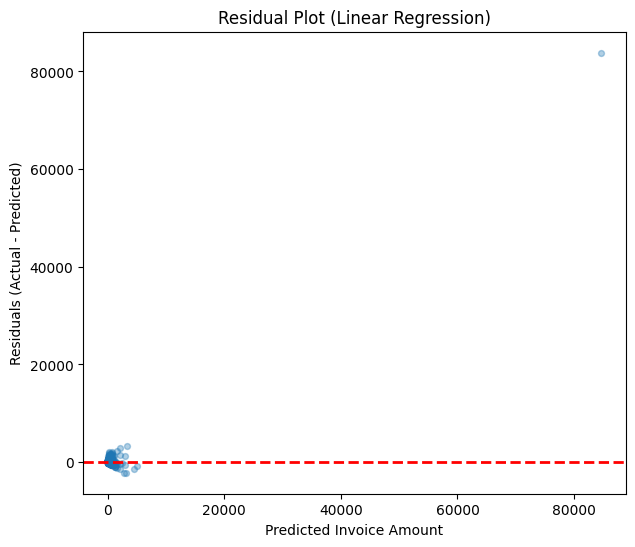

In [76]:
# ============================================================
# Residual Plot - Linear Regression
# ============================================================

# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(7,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.35,
    s=18
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=2
)

plt.xlabel("Predicted Invoice Amount")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Linear Regression)")

plt.show()

### Observation

The residual plot shows that the majority of residuals are concentrated close to the zero reference line, indicating that the Linear Regression model predicts most transactions with reasonable accuracy.

However, one exceptionally large positive residual is clearly visible, corresponding to a high-value invoice that was substantially under-predicted by the model. This suggests that the baseline Linear Regression model has difficulty accurately predicting extreme transaction values.

Apart from this outlier, the residuals do not exhibit any strong systematic pattern, indicating that the model provides an acceptable fit for the majority of observations. The presence of a few extreme residuals is expected because the Online Retail dataset contains highly skewed invoice amounts with several large purchases.

### Residual Plot (Zoomed View)

To better visualize the residual distribution for the majority of transactions, a zoomed view of the residual plot is shown below. This excludes the visual dominance of extreme outliers while retaining all observations in the analysis.

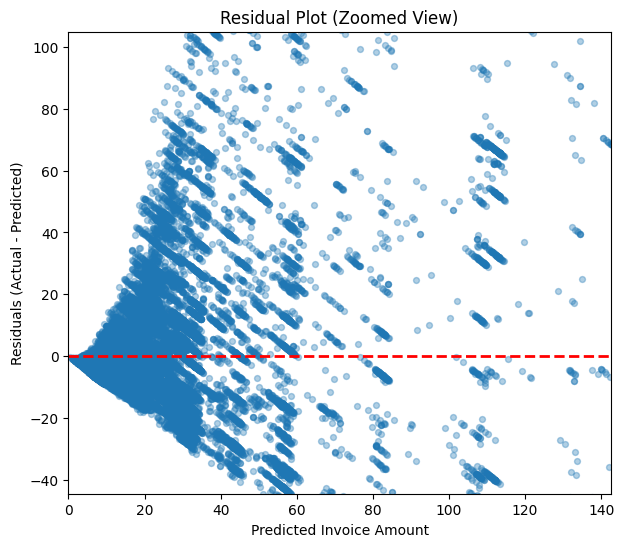

In [77]:
# ============================================================
# Residual Plot (Zoomed View)
# ============================================================

plt.figure(figsize=(7,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.35,
    s=18
)

plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

# Zoom to show the majority of observations
plt.xlim(0, np.percentile(y_pred, 99))
plt.ylim(
    np.percentile(residuals, 1),
    np.percentile(residuals, 99)
)

plt.xlabel("Predicted Invoice Amount")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Zoomed View)")

plt.show()

### Observation

The zoomed residual plot provides a clearer view of the prediction errors for the majority of transactions after reducing the visual impact of extreme outliers.

Most residuals are distributed around the zero reference line, indicating that the Linear Regression model provides reasonably accurate predictions for typical invoice amounts. However, the spread of residuals gradually increases as the predicted invoice amount increases, suggesting that prediction errors become larger for higher-value transactions.

This pattern indicates mild heteroscedasticity, which is commonly observed in retail sales datasets with highly skewed transaction values. Overall, the residual analysis suggests that the baseline Linear Regression model performs well for most transactions but is less effective in predicting large invoice amounts.

# Initial Model Comparison – Decision Tree Regressor

To evaluate whether a non-linear model performs better than the baseline Linear Regression model, a Decision Tree Regressor is implemented and its performance is compared using the same training and testing datasets.

In [79]:
# ============================================================
# Decision Tree Regressor
# ============================================================

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Model Trained Successfully")

print("R2 Score :", r2_score(y_test, dt_pred))

print("MAE :", mean_absolute_error(y_test, dt_pred))

print("RMSE :", mean_squared_error(y_test, dt_pred)**0.5)

Decision Tree Model Trained Successfully
R2 Score : 0.70976989119019
MAE : 1.4963969492865619
RMSE : 326.25978381572213


# Hyperparameter Tuning

Hyperparameter tuning was performed to improve the performance of the Decision Tree Regressor. GridSearchCV was used with 3-fold cross-validation to evaluate different values of the **max_depth** parameter.

The objective was to identify the tree depth that provides the best balance between prediction accuracy and model generalization while reducing the risk of overfitting.

In [80]:
# ============================================================
# Hyperparameter Tuning
# ============================================================

from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3,5,7,10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Parameter :", grid.best_params_)

best_dt = grid.best_estimator_

best_pred = best_dt.predict(X_test)

print("Tuned R2 Score :", r2_score(y_test, best_pred))

Best Parameter : {'max_depth': 10}
Tuned R2 Score : 0.709773236744246


### Observation

GridSearchCV identified **max_depth = 10** as the optimal parameter for the Decision Tree Regressor.

The tuned model achieved an **R² Score of 0.710**, which is very similar to the untuned Decision Tree model. This indicates that the default model was already performing close to its optimal configuration on the cleaned dataset, and further increases in tree depth were unlikely to produce substantial improvements.

This experiment demonstrates the importance of hyperparameter tuning as part of the machine learning workflow, even when the resulting performance improvement is modest.

# Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. Unlike a single Decision Tree, Random Forest averages the predictions from many trees, resulting in better generalization and more stable performance.

The model is evaluated using the same training and testing datasets to enable fair comparison with the Linear Regression and Decision Tree models.

In [82]:
# ============================================================
# Random Forest Regressor
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Model Trained Successfully")

print("R2 Score :", r2_score(y_test, rf_pred))

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", mean_squared_error(y_test, rf_pred)**0.5)

Random Forest Model Trained Successfully
R2 Score : 0.5040401239331009
MAE : 1.778610886438682
RMSE : 426.49660962731855


# Model Comparison

The performance of the developed regression models was compared using three evaluation metrics: R² Score, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE). The comparison helps identify the model that provides the best balance between prediction accuracy and generalization.

In [83]:
# ============================================================
# Model Comparison
# ============================================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R² Score": [
        round(r2_score(y_test, y_pred), 3),
        round(r2_score(y_test, dt_pred), 3),
        round(r2_score(y_test, rf_pred), 3)
    ],
    "MAE": [
        round(mean_absolute_error(y_test, y_pred), 2),
        round(mean_absolute_error(y_test, dt_pred), 2),
        round(mean_absolute_error(y_test, rf_pred), 2)
    ],
    "RMSE": [
        round(mean_squared_error(y_test, y_pred)**0.5, 2),
        round(mean_squared_error(y_test, dt_pred)**0.5, 2),
        round(mean_squared_error(y_test, rf_pred)**0.5, 2)
    ]
})

display(comparison)

,Model,R² Score,MAE,RMSE
0,Linear Regression,0.749,13.27,303.14
1,Decision Tree,0.710,1.50,326.26
2,Random Forest,0.504,1.78,426.50


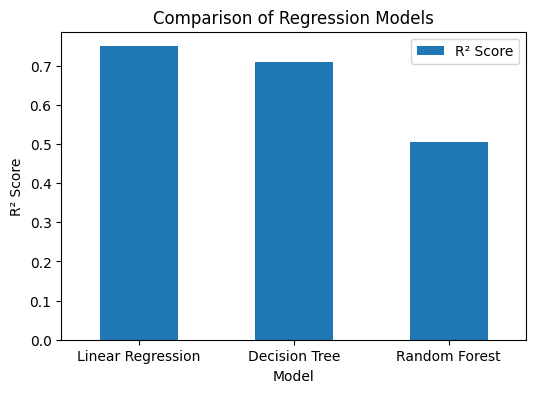

In [85]:
comparison.plot(
    x="Model",
    y="R² Score",
    kind="bar",
    figsize=(6,4)
)

plt.ylabel("R² Score")
plt.title("Comparison of Regression Models")
plt.xticks(rotation=0)
plt.show()

### Observation

The comparison of regression models indicates that **Linear Regression** achieved the highest R² Score (0.749), demonstrating the best overall predictive performance on the cleaned dataset. The **Decision Tree Regressor** achieved a slightly lower R² Score (0.710) while producing a lower Mean Absolute Error (MAE), indicating good prediction accuracy for many individual observations. The **Random Forest Regressor** achieved the lowest R² Score (0.504), suggesting comparatively weaker predictive performance for this particular dataset.

The results demonstrate that different machine learning algorithms respond differently to the characteristics of the dataset and the applied preprocessing steps. Therefore, evaluating multiple models is important for selecting the most appropriate regression technique.

The comparison demonstrates that model selection should be guided by multiple evaluation metrics and business objectives rather than relying solely on a single performance measure.

# Feature Importance

Feature importance analysis helps identify which predictor variables contribute most to the model's predictions. Understanding feature importance improves model interpretability and provides useful business insights into the factors influencing retail sales.

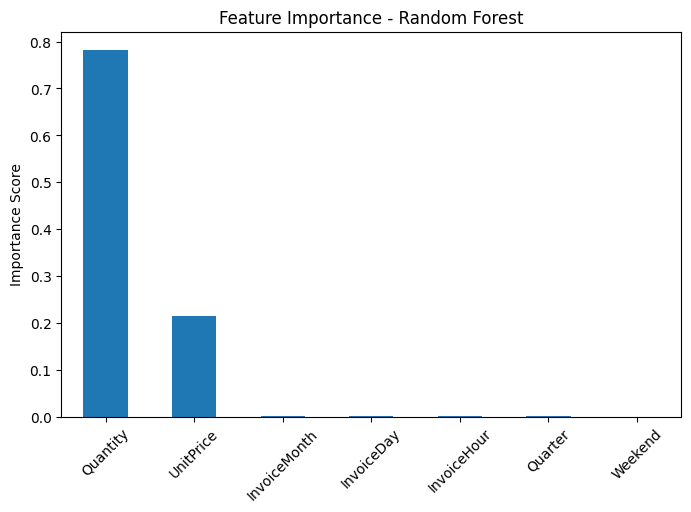

In [86]:
# Feature Importance from Random Forest

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,5))

importance.plot(kind="bar")

plt.title("Feature Importance - Random Forest")

plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

### Observation

The feature importance analysis indicates that **Quantity** is the most influential predictor of **InvoiceAmount**, contributing the largest importance score among all variables. **UnitPrice** is the second most important feature, while the temporal features (**InvoiceMonth**, **InvoiceDay**, **InvoiceHour**, **Quarter**, and **Weekend**) contribute relatively little to the model's predictions.

These findings are consistent with the earlier correlation analysis, where **Quantity** showed the strongest relationship with the target variable. This suggests that the number of items purchased is the primary driver of retail transaction value, whereas the timing of transactions has a comparatively smaller influence.

# Overfitting and Generalization Discussion

The developed regression models were evaluated using a separate testing dataset created through an 80:20 train-test split. This approach helps assess how well each model generalizes to unseen data.

The comparison of evaluation metrics indicates that different models exhibit different predictive behaviours. Linear Regression provided the highest overall R² Score, demonstrating better generalization on the cleaned dataset. The Decision Tree Regressor achieved a lower Mean Absolute Error (MAE), indicating accurate predictions for many observations, while the Random Forest Regressor produced comparatively weaker performance for this dataset.

These results highlight the importance of evaluating multiple algorithms and selecting the most appropriate model based on several performance metrics rather than relying on a single measure of accuracy.

# Preliminary Evaluation

Three regression models were developed and evaluated for predicting retail invoice amounts using the cleaned Online Retail dataset.

| Model | R² Score | MAE | RMSE |
|------|---------:|---------:|---------:|
| Linear Regression | **0.749** | **13.27** | **303.14** |
| Decision Tree Regressor | **0.710** | **1.50** | **326.26** |
| Random Forest Regressor | **0.504** | **1.78** | **426.50** |

### Evaluation Summary

The comparison indicates that **Linear Regression** achieved the highest overall R² Score, demonstrating the best predictive performance on the cleaned dataset.

The **Decision Tree Regressor** achieved a slightly lower R² Score but produced the lowest Mean Absolute Error (MAE), indicating accurate predictions for many individual transactions.

The **Random Forest Regressor** produced comparatively lower predictive performance on this dataset, illustrating that ensemble methods do not always outperform simpler models.

Overall, evaluating multiple regression algorithms provided valuable insight into the behaviour of different machine learning models and helped identify the most suitable approach for this retail sales prediction problem.

# Business Recommendations

Based on the exploratory data analysis and model evaluation, the following business recommendations are proposed:

### 1. Improve Inventory Planning

Sales trends indicate seasonal variations in purchasing behaviour. Maintaining adequate inventory before peak sales periods can reduce stock shortages and improve customer satisfaction.

### 2. Focus on High-Volume Transactions

Transaction quantity was identified as the strongest predictor of invoice amount. Businesses should ensure that frequently purchased products remain readily available and are effectively promoted.

### 3. Use Predictive Analytics for Sales Planning

The developed regression models can assist in forecasting invoice amounts, enabling better demand forecasting, procurement planning, and financial management.

### 4. Monitor High-Value Transactions Separately

A small number of exceptionally large invoices were observed during the analysis. These transactions have a significant influence on prediction accuracy and should be monitored individually for better business decision-making.

### 5. Continue Improving Data Quality

Accurate customer information and complete transaction records improve the reliability of predictive models. Maintaining high-quality transactional data will support more effective business analytics.

# Project Limitations

This project has several limitations that should be considered when interpreting the results:

- The dataset contains highly skewed invoice amounts with several extreme outliers that influence regression performance.

- The analysis is based on historical transactional data from a single online retailer and may not generalize to all retail businesses.

- External business factors such as promotions, holidays, competitor pricing, and economic conditions were not available in the dataset.

- Customer demographic information was unavailable, limiting customer-level behavioural analysis.

- More advanced machine learning techniques and additional feature engineering may further improve predictive performance in future work.

# Future Work

Although the developed regression models achieved satisfactory predictive performance, several enhancements could be explored in future work.

- Develop customer-level behavioural features such as purchase frequency, recency, and average basket value.
- Explore additional ensemble learning algorithms such as XGBoost and LightGBM.
- Apply advanced feature selection techniques to identify the most informative predictors.
- Investigate logarithmic target transformation to further reduce the effect of highly skewed invoice amounts.
- Perform more extensive hyperparameter tuning using a wider parameter search space.
- Evaluate the models using additional validation techniques such as repeated cross-validation.
- Develop interactive dashboards to visualize sales trends and model predictions for business users.

These improvements may further enhance predictive performance and provide deeper business insights for retail decision-making.

# Final Project Conclusion

This project successfully implemented an end-to-end machine learning workflow for predicting retail invoice amounts using the Online Retail dataset obtained from the UCI Machine Learning Repository.

The project included data inspection, data cleaning, exploratory data analysis, feature engineering, model development, hyperparameter tuning, model comparison, feature importance analysis, and performance evaluation.

Exploratory Data Analysis revealed that the majority of transactions originated from the United Kingdom and that retail sales increased noticeably during the final quarter of the year. The distribution of invoice amounts was highly right-skewed, indicating that most transactions were of relatively low value while a small number of transactions represented exceptionally high purchases.

Feature engineering generated additional temporal variables that were incorporated into the modelling process. Feature importance analysis demonstrated that **Quantity** and **UnitPrice** were the primary factors influencing retail invoice amounts, while temporal variables contributed comparatively less.

Three regression models were developed and compared. Among them, **Linear Regression** achieved the highest overall R² Score on the cleaned dataset, while the Decision Tree Regressor produced competitive predictive performance. Hyperparameter tuning further demonstrated the importance of optimizing model parameters as part of the machine learning workflow.

Overall, this project demonstrates how machine learning techniques can be effectively applied to retail transaction data to support sales prediction, improve business understanding, and assist data-driven decision making.

# Final Project Summary

This project successfully implemented an end-to-end machine learning workflow for predicting retail invoice amounts using the Online Retail dataset obtained from the UCI Machine Learning Repository.

The project included data inspection, data cleaning, exploratory data analysis, feature engineering, model development, hyperparameter tuning, model comparison, feature importance analysis, and performance evaluation.

Exploratory Data Analysis revealed that the majority of transactions originated from the United Kingdom and that retail sales increased noticeably during the final quarter of the year. The distribution of invoice amounts was highly right-skewed, indicating that most transactions were of relatively low value while a small number of transactions represented exceptionally high purchases.

Feature engineering generated additional temporal variables that were incorporated into the modelling process. Feature importance analysis demonstrated that **Quantity** and **UnitPrice** were the primary factors influencing retail invoice amounts, while temporal variables contributed comparatively less.

Three regression models were developed and compared. Among them, **Linear Regression** achieved the highest overall R² Score on the cleaned dataset, while the Decision Tree Regressor produced competitive predictive performance. Hyperparameter tuning further demonstrated the importance of optimizing model parameters as part of the machine learning workflow.

Overall, this project demonstrates how machine learning techniques can be effectively applied to retail transaction data to support sales prediction, improve business understanding, and assist data-driven decision making.

# Final Project Summary

This project successfully implemented an end-to-end machine learning workflow for predicting retail invoice amounts using the Online Retail dataset obtained from the UCI Machine Learning Repository.

The project included data inspection, data cleaning, exploratory data analysis, feature engineering, model development, hyperparameter tuning, model comparison, feature importance analysis, and performance evaluation.

Exploratory Data Analysis revealed that the majority of transactions originated from the United Kingdom and that retail sales increased noticeably during the final quarter of the year. The distribution of invoice amounts was highly right-skewed, indicating that most transactions were of relatively low value while a small number of transactions represented exceptionally high purchases.

Feature engineering generated additional temporal variables that were incorporated into the modelling process. Feature importance analysis demonstrated that **Quantity** and **UnitPrice** were the primary factors influencing retail invoice amounts, while temporal variables contributed comparatively less.

Three regression models were developed and compared. Among them, **Linear Regression** achieved the highest overall R² Score on the cleaned dataset, while the Decision Tree Regressor produced competitive predictive performance. Hyperparameter tuning further demonstrated the importance of optimizing model parameters as part of the machine learning workflow.

Overall, this project demonstrates how machine learning techniques can be effectively applied to retail transaction data to support sales prediction, improve business understanding, and assist data-driven decision making.

# End of Project

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------